# Module 6 Lab: SQL + pandas

**Repo URL:** https://github.com/washingtonjustin02smc/CS82A-repository/tree/module6


## Step 1: Load the CSVs and build the database

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

orders = pd.read_csv("store_orders.csv")
customers = pd.read_csv("store_customers.csv")

con = sqlite3.connect("store.db")
orders.to_sql("orders", con, index=False, if_exists="replace")
customers.to_sql("customers", con, index=False, if_exists="replace")

pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", con)

,name
0,customers
1,orders


## Step 2: First look

In [2]:
pd.read_sql("SELECT * FROM orders LIMIT 5", con)

,order_id,customer_id,product,category,amount,order_date
0,5000,4,paper,office,14.09,2026-05-25
1,5001,15,planner,office,51.86,2026-05-08
2,5002,34,shelf,furniture,116.25,2026-06-03
3,5003,2,granola,snacks,19.72,2026-05-19
4,5004,17,monitor,electronics,284.80,2026-05-10


## Step 3: Filter and sort

In [3]:
step3 = pd.read_sql("""
SELECT *
FROM orders
WHERE amount > 100
ORDER BY amount DESC;
""", con)
step3

,order_id,customer_id,product,category,amount,order_date
0,5153,20,dock,electronics,499.00,2026-05-25
1,5140,30,headset,electronics,295.36,2026-05-26
2,5047,901,headset,electronics,293.79,2026-05-15
3,5150,903,monitor,electronics,293.35,2026-06-06
4,5014,6,monitor,electronics,287.83,2026-05-22
...,...,...,...,...,...,...
79,5107,38,shelf,furniture,110.31,2026-05-17
80,5046,13,shelf,furniture,108.47,2026-05-28
81,5009,14,chair,furniture,107.20,2026-05-24
82,5007,36,dock,electronics,103.77,2026-05-21


## Step 4: Aggregate by category

In [4]:
step4 = pd.read_sql("""
SELECT category, COUNT(*) AS n, AVG(amount) AS avg_amount
FROM orders
GROUP BY category
ORDER BY avg_amount DESC;
""", con)
step4

,category,n,avg_amount
0,electronics,60,190.569500
1,furniture,46,146.251522
2,office,51,30.132549
3,snacks,43,14.619767


Electronics earns the most per order because it has the highest average order amount.

## Step 5: Join for spend by city

In [5]:
step5 = pd.read_sql("""
SELECT c.city, SUM(o.amount) AS total_spend
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.city
ORDER BY total_spend DESC;
""", con)
step5

,city,total_spend
0,Los Angeles,5862.99
1,Culver City,5316.88
2,Santa Monica,4017.93
3,Inglewood,2718.25
4,Torrance,1037.25
5,Venice,462.36


## Step 6: Row-count audit

In [6]:
order_count = pd.read_sql("SELECT COUNT(*) AS order_rows FROM orders", con)
join_count = pd.read_sql("""
SELECT COUNT(*) AS joined_rows
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id;
""", con)

pd.concat([order_count, join_count], axis=1)

,order_rows,joined_rows
0,200,195


The orders table has 200 rows, but after joining it with the customers table, there are 195 matching orders. The difference is because 5 orders have customer IDs that don’t match any customer in the customers table, so the inner join leaves those orders out.

## Step 7: Chart a query result

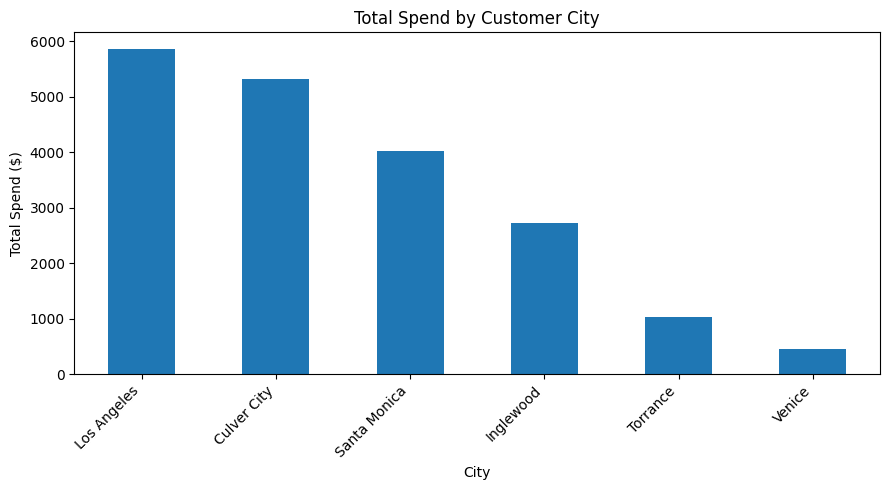

In [7]:
ax = step5.plot(kind="bar", x="city", y="total_spend", legend=False, figsize=(9, 5))
ax.set_title("Total Spend by Customer City")
ax.set_xlabel("City")
ax.set_ylabel("Total Spend ($)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Step 8: Your own question

**Business question:** Which customer signup year generated the most total sales?

In [8]:
step8 = pd.read_sql("""
SELECT c.signup_year, SUM(o.amount) AS total_sales
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.signup_year
ORDER BY total_sales DESC;
""", con)
step8

,signup_year,total_sales
0,2021,5238.70
1,2026,4929.49
2,2022,3288.13
3,2023,2692.97
4,2024,2054.51
5,2025,1211.86


I wanted to see which customer signup year was responsible for the most total spending. I put together the customers by signup year and calculated the total amount spent by each group. The results show that customers who signed up in 2021 generated the highest total sales, with $5,238.70.

## Step 9: Ethics note and safe push

Before sharing this data, I would remove customer names and avoid showing customer records. I would group the information by categories such as city or signup year so the results are still useful without exposing personal customer information.

## AI Use Appendix

**Tool:** ChatGPT

**Key prompts:** Helped debug SQL syntax and verify that the JOIN, GROUP BY, SUM, and ORDER BY queries ran correctly. The Step 8 SQL query was checked for syntax after it was written.